In [1]:
# Import library yang kalian butuhkan
import sys
import os
import importlib

# Auto-detect environment
try:
    IS_COLAB = 'COLAB_GPU' in os.environ or 'google.colab' in str(get_ipython())
except NameError:
    IS_COLAB = False

if IS_COLAB:
    # Auto-setup for Google Colab if files are missing
    if not os.path.exists('all-script-accelerated.py') or not os.path.exists('fgvc-aircraft'):
        print("Running on Google Colab. Auto-setting up directory and installing packages...")
        # Clone the github repository
        get_ipython().system('git clone https://github.com/Schryzon/AeroVision.git')
        # Move repository files into the main working directory
        get_ipython().system('mv AeroVision/* .')
        get_ipython().system('mv AeroVision/.[!.]* . 2>/dev/null || true')
        # Install dependencies
        get_ipython().system('pip install -r requirements.txt')
        print("Colab environment setup complete!")

import numpy as np
import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Setup parent path so we can import the local all-script-accelerated module
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
acc = importlib.import_module('all-script-accelerated')

# Display GPU status
acc.gpu_info()


[accelerated] 🚀 GPU: NVIDIA GeForce RTX 3050 Laptop GPU (4095 MB) | auto ≥256px
🚀 GPU backend  : CuPy + CUDA (NVIDIA GeForce RTX 3050 Laptop GPU)
📐 Smart dispatch: images ≥256×256 → GPU, smaller → CPU
💾 VRAM          : 4095 MB


## Data Loading


Buat struktur folder dataset sebagai berikut:
```
.
└──dataset
    ├── label1
	├── image1.jpg
	├── image2.jpg
	└── image3.jpg
    ├── label2
    └── label3
    └── dst...
```


In [2]:
import os
import shutil
import cv2 as cv
import numpy as np
import pandas as pd

# 1. Environment Detection & Dataset Organization (Windows local vs Colab)
IS_COLAB = 'COLAB_GPU' in os.environ or 'google.colab' in str(get_ipython())

# Google Drive integration for Google Colab
if IS_COLAB:
    if not os.path.exists('/content/drive'):
        print("Mounting Google Drive to access the dataset...")
        try:
            from google.colab import drive
            drive.mount('/content/drive')
        except Exception as e:
            print("Google Drive mount failed:", e)

csv_paths = [
    'fgvc-aircraft/train.csv',
    'fgvc-aircraft/val.csv',
    'fgvc-aircraft/test.csv'
]

# Read and merge all 3 CSVs
df_list = []
for path in csv_paths:
    if os.path.exists(path):
        df_list.append(pd.read_csv(path))
    else:
        colab_path = os.path.join('/content', path)
        drive_path = os.path.join('/content/drive/MyDrive', path)
        if os.path.exists(colab_path):
            df_list.append(pd.read_csv(colab_path))
        elif os.path.exists(drive_path):
            df_list.append(pd.read_csv(drive_path))

if len(df_list) == 0:
    raise FileNotFoundError("Could not find any fgvc-aircraft CSV files (train.csv, val.csv, test.csv).")

df_merged = pd.concat(df_list, ignore_index=True)
print(f"Total merged CSV entries: {len(df_merged)}")

src_images_dir = 'fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images/'
dst_dataset_dir = 'dataset/'

if not os.path.exists(src_images_dir):
    # Try Google Drive path first, then local Colab clone folder
    drive_images_dir = '/content/drive/MyDrive/fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images/'
    colab_images_dir = '/content/fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images/'
    
    if os.path.exists(drive_images_dir):
        src_images_dir = drive_images_dir
    elif os.path.exists(colab_images_dir):
        src_images_dir = colab_images_dir

if not os.path.exists(src_images_dir):
    print("\n[!] DATASET IMAGES NOT FOUND.")
    print("Please upload your 'fgvc-aircraft-2013b' directory to Colab, or place it in Google Drive under:")
    print("  'My Drive/fgvc-aircraft/fgvc-aircraft-2013b/'")
    raise FileNotFoundError(f"Source images directory not found at: {src_images_dir}")

os.makedirs(dst_dataset_dir, exist_ok=True)

success_count = 0
symlink_count = 0
copy_count = 0

print("Organizing dataset folders...")
for index, row in df_merged.iterrows():
    img_name = row['filename']
    class_name = str(row['Classes']).strip()
    
    class_dir = os.path.join(dst_dataset_dir, class_name)
    os.makedirs(class_dir, exist_ok=True)
    
    src_file = os.path.join(src_images_dir, img_name)
    dst_file = os.path.join(class_dir, img_name)
    
    if os.path.exists(dst_file):
        success_count += 1
        continue
        
    if not os.path.exists(src_file):
        continue
        
    if not IS_COLAB:
        try:
            os.symlink(os.path.abspath(src_file), os.path.abspath(dst_file))
            symlink_count += 1
            success_count += 1
            continue
        except Exception:
            pass  # Fallback to copy if symlinks are not allowed (no admin privileges)
            
    shutil.copy2(src_file, dst_file)
    copy_count += 1
    success_count += 1

print(f"Dataset organized! Total: {success_count} (Symlink: {symlink_count}, Copy: {copy_count})")

# 2. Loading organized images into memory & resizing to 256x256
data = []
labels = []
file_name = []

print("Loading and resizing images to 256x256...")
sub_folders = os.listdir(dst_dataset_dir)
for sub_folder in sub_folders:
    sub_folder_path = os.path.join(dst_dataset_dir, sub_folder)
    if not os.path.isdir(sub_folder_path):
        continue
    sub_folder_files = os.listdir(sub_folder_path)
    for filename in sub_folder_files:
        img_path = os.path.join(sub_folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        img = img.astype(np.uint8)
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        
        # GPU/CPU resize to 256x256
        img = acc.resize(img, 256, 256)
        
        # Wrap with to_cpu to guarantee numpy array
        data.append(acc.to_cpu(img))
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)
print(f"Successfully loaded {len(data)} images.")


Total merged CSV entries: 10000
Organizing dataset folders...
Dataset organized! Total: 10000 (Symlink: 0, Copy: 0)
Loading and resizing images to 256x256...
Successfully loaded 9800 images.


## Data Augmentation


### Define Augmentation Function


In [3]:
# melakukan augmentasi data
data_augmented = []
labels_augmented = []
file_name_augmented = []

print("Augmenting data using GPU-accelerated operations...")
for i in range(len(data)):
    img = data[i]
    lbl = labels[i]
    fname = file_name[i]
    
    # Original image
    data_augmented.append(acc.to_cpu(img))
    labels_augmented.append(lbl)
    file_name_augmented.append(fname)
    
    # 1. Horizontal Flip (accelerated)
    flipped = acc.to_cpu(acc.Image_Ops.flip(img, axis='horizontal'))
    data_augmented.append(flipped)
    labels_augmented.append(lbl)
    file_name_augmented.append(f"{os.path.splitext(fname)[0]}_flip.jpg")
    
    # 2. Slight rotation (accelerated - 15 degrees CCW)
    # Resized back to 256x256 since rotation changes canvas size
    rotated = acc.to_cpu(acc.Image_Ops.rotate(img, angle=15.0, direction='ccw'))
    rotated = acc.to_cpu(acc.resize(rotated, 256, 256))
    data_augmented.append(rotated)
    labels_augmented.append(lbl)
    file_name_augmented.append(f"{os.path.splitext(fname)[0]}_rot15.jpg")

data_augmented = np.array(data_augmented)
labels_augmented = np.array(labels_augmented)
print("Augmentation completed!")


Augmenting data using GPU-accelerated operations...
Augmentation completed!


In [4]:
print("Data sebelum augmentasi: ", len(data))
print("Data setelah augmentasi: ", len(data_augmented))


Data sebelum augmentasi:  9800
Data setelah augmentasi:  29400


## Data Preparation


### Define Preprocessing Function

#### Preprocessing Methods Justification:
To achieve optimal class separation for commercial aircraft classification, a structured 3-stage preprocessing system is utilized:

1. **Stage 1: Noise Reduction (Gaussian & Median Blur)**
   - **Gaussian Blur (kernel_size=3)**: Acts as a low-pass filter that effectively suppresses high-frequency Gaussian noise (typically caused by image acquisition sensors and compression artifacts).
   - **Median Blur (kernel_size=3)**: Extremely robust at preserving sharp boundaries (such as wings, tail fins, and fuselage outlines) while completely removing impulsive salt-and-pepper noise.

2. **Stage 2: Contrast Enhancement (CLAHE & Gamma Correction)**
   - **CLAHE (Contrast Limited Adaptive Histogram Equalization, clip_limit=2.0)**: Enhances local contrast of the aircraft against varying skies, clouds, and runway backgrounds. By applying local histogram equalization with a contrast limit, it prevents over-saturation of noise in homogeneous image sectors.
   - **Gamma Correction (gamma=0.9)**: Compensates for varying brightness conditions. A gamma value of 0.9 slightly shifts intensity values to emphasize details in shaded structures (like the underbelly and engine nacelles) which are critical for model differentiation.

3. **Stage 3: Detail & Edge Enhancement (Unsharp Mask & Sharpening)**
   - **Unsharp Masking (sigma=1.0, strength=1.5)**: Subtracts a smoothed/blurred version of the image from the original. This amplifies fine details, surface textures, and boundaries.
   - **Sharpening filter (Convolution kernel)**: A final high-pass boost that accentuates structural contours and metallic patterns, making the texture features computed by the subsequent GLCM pass significantly more distinctive.


In [5]:
def resize(image, target_size=(256, 256)):
    return acc.resize(image, target_size[0], target_size[1])

# Stage 1: Noise Reduction (2 methods)
def prepro1(image):
    img = acc.Enhancement.blur_gaussian(image, kernel_size=3)
    img = acc.Enhancement.blur_median(img, kernel_size=3)
    return img

# Stage 2: Contrast Enhancement (2 methods)
def prepro2(image):
    img = acc.Equalization.clahe(image, clip_limit=2.0)
    img = acc.Enhancement.gamma_correction(img, gamma=0.9)
    return img

# Stage 3: Detail/Edge Enhancement (2 methods)
def prepro3(image):
    img = acc.Enhancement.unsharp_mask(image, sigma=1.0, strength=1.5)
    img = acc.Enhancement.sharpen(img)
    return img


### Preprocessing


In [6]:
# pada bagian ini bisa gunakan data yang sebelum augmentasi atau setelah augmentasi
# Kita menggunakan data sebelum augmentasi (10k gambar) untuk kecepatan pengerjaan.
dataPreprocessed = []
print("Running 3-stage preprocessing pipeline...")
for i in range(len(data)):
    if i % 2000 == 0:
        print(f"Preprocessing image {i}/{len(data)}")
    img = data[i]
    img = prepro1(img)
    img = prepro2(img)
    img = prepro3(img)
    # Wrap with acc.to_cpu to resolve any CuPy arrays to NumPy arrays
    dataPreprocessed.append(acc.to_cpu(img))
    
dataPreprocessed = np.array(dataPreprocessed)
print(f"Preprocessing completed for {len(dataPreprocessed)} images.")


Running 3-stage preprocessing pipeline...
Preprocessing image 0/9800
Preprocessing image 2000/9800
Preprocessing image 4000/9800
Preprocessing image 6000/9800
Preprocessing image 8000/9800
Preprocessing completed for 9800 images.


### Feature Extraction


In [7]:
def glcm(image, derajat):
    # Forward call directly to the pre-existing, optimized GLCM implementation in all-script
    g = acc.GLCM.compute(image, distance=1, angle=float(derajat), levels=256, symmetric=True)
    return acc.GLCM.normalize(g)


In [8]:
def correlation(matriks):
    # delegates property calculation to all-script without re-implementing GLCM features
    return acc.GLCM._compute_features(matriks, extract_asm=True)['correlation']


In [9]:
def dissimilarity(matriks):
    # delegates property calculation to all-script without re-implementing GLCM features
    return acc.GLCM._compute_features(matriks, extract_asm=True)['dissimilarity']


In [10]:
def homogenity(matriks):
    # delegates property calculation to all-script without re-implementing GLCM features
    return acc.GLCM._compute_features(matriks, extract_asm=True)['homogeneity']


In [11]:
def contrast(matriks):
    # delegates property calculation to all-script without re-implementing GLCM features
    return acc.GLCM._compute_features(matriks, extract_asm=True)['contrast']


In [12]:
def ASM(matriks):
    # delegates property calculation to all-script without re-implementing GLCM features
    return acc.GLCM._compute_features(matriks, extract_asm=True)['asm']


In [13]:
def energy(matriks):
    # delegates property calculation to all-script without re-implementing GLCM features
    return acc.GLCM._compute_features(matriks, extract_asm=True)['energy']


In [14]:
def entropyGlcm(matriks):
    # delegates property calculation to all-script without re-implementing GLCM features
    return acc.GLCM._compute_features(matriks, extract_asm=True)['entropy']


In [15]:
print("Batch-extracting GLCM features from all preprocessed images in a single optimized pass...")
features_dict = acc.GLCM.extract_batch(dataPreprocessed, distances=(1,), angles=(0, 45, 90, 135))
print("Batch extraction completed!")


Batch-extracting GLCM features from all preprocessed images in a single optimized pass...
Batch extraction completed!


In [16]:
# Unpack the batch features directly into respective variables. No loops are needed!
Kontras0 = features_dict['Contrast0']
Kontras45 = features_dict['Contrast45']
Kontras90 = features_dict['Contrast90']
Kontras135 = features_dict['Contrast135']

dissimilarity0 = features_dict['Dissimilarity0']
dissimilarity45 = features_dict['Dissimilarity45']
dissimilarity90 = features_dict['Dissimilarity90']
dissimilarity135 = features_dict['Dissimilarity135']

homogenity0 = features_dict['Homogeneity0']
homogenity45 = features_dict['Homogeneity45']
homogenity90 = features_dict['Homogeneity90']
homogenity135 = features_dict['Homogeneity135']

entropy0 = features_dict['Entropy0']
entropy45 = features_dict['Entropy45']
entropy90 = features_dict['Entropy90']
entropy135 = features_dict['Entropy135']

ASM0 = features_dict['ASM0']
ASM45 = features_dict['ASM45']
ASM90 = features_dict['ASM90']
ASM135 = features_dict['ASM135']

energy0 = features_dict['Energy0']
energy45 = features_dict['Energy45']
energy90 = features_dict['Energy90']
energy135 = features_dict['Energy135']

correlation0 = features_dict['Correlation0']
correlation45 = features_dict['Correlation45']
correlation90 = features_dict['Correlation90']
correlation135 = features_dict['Correlation135']


In [17]:
# Fully processed and unpacked in previous cells (vectorized)


In [18]:
# Fully processed and unpacked in previous cells (vectorized)


In [19]:
# Fully processed and unpacked in previous cells (vectorized)


In [20]:
# Fully processed and unpacked in previous cells (vectorized)


In [21]:
# Fully processed and unpacked in previous cells (vectorized)


In [22]:
# Fully processed and unpacked in previous cells (vectorized)


In [23]:
# Fully processed and unpacked in previous cells (vectorized)


### Write the extraction's results to CSV 


In [24]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_1.csv')
print(f"Feature matrix loaded. Shape: {hasilEkstrak.shape}")
hasilEkstrak.head()


Feature matrix loaded. Shape: (9800, 30)


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,0056978.jpg,707-320,1419.900980,3074.954710,3029.473637,2883.957401,0.135954,0.076364,0.080709,0.079099,...,0.000732,0.000710,0.041430,0.025301,0.027051,0.026643,0.834980,0.639128,0.646677,0.661543
1,0062765.jpg,707-320,2349.532904,4359.043368,4208.891161,4405.967120,0.150821,0.097004,0.107394,0.097209,...,0.001986,0.001670,0.066781,0.040658,0.044565,0.040862,0.834687,0.692033,0.703091,0.688721
2,0062781.jpg,707-320,2010.075230,3026.937824,2820.076624,2895.680707,0.119431,0.085791,0.097033,0.087908,...,0.001506,0.001113,0.049012,0.032336,0.038801,0.033355,0.766739,0.645292,0.670352,0.660690
3,0063435.jpg,707-320,2237.032935,4111.806644,3747.884482,4035.639769,0.255048,0.196369,0.203586,0.196869,...,0.018104,0.017404,0.162634,0.132120,0.134551,0.131926,0.861165,0.744040,0.766840,0.748786
4,0064932.jpg,707-320,1101.977681,2391.402368,2451.066437,2496.237555,0.135134,0.077131,0.079587,0.076861,...,0.000404,0.000338,0.035827,0.019315,0.020098,0.018374,0.899388,0.780232,0.775455,0.770599


### Features Selection


pada bagian seleksi fitur ini bisa menggunakan metode seperti
- PCA
- LDA
- t-SNE
- Chi-square
- ANOVA
- Autoencoder
- correlation
- dll

berikut contoh menggunakan correlation:


Selected features count: 11 / 28
Selected features: ['Contrast0', 'Contrast45', 'Homogeneity0', 'Dissimilarity0', 'Entropy0', 'ASM0', 'Energy0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


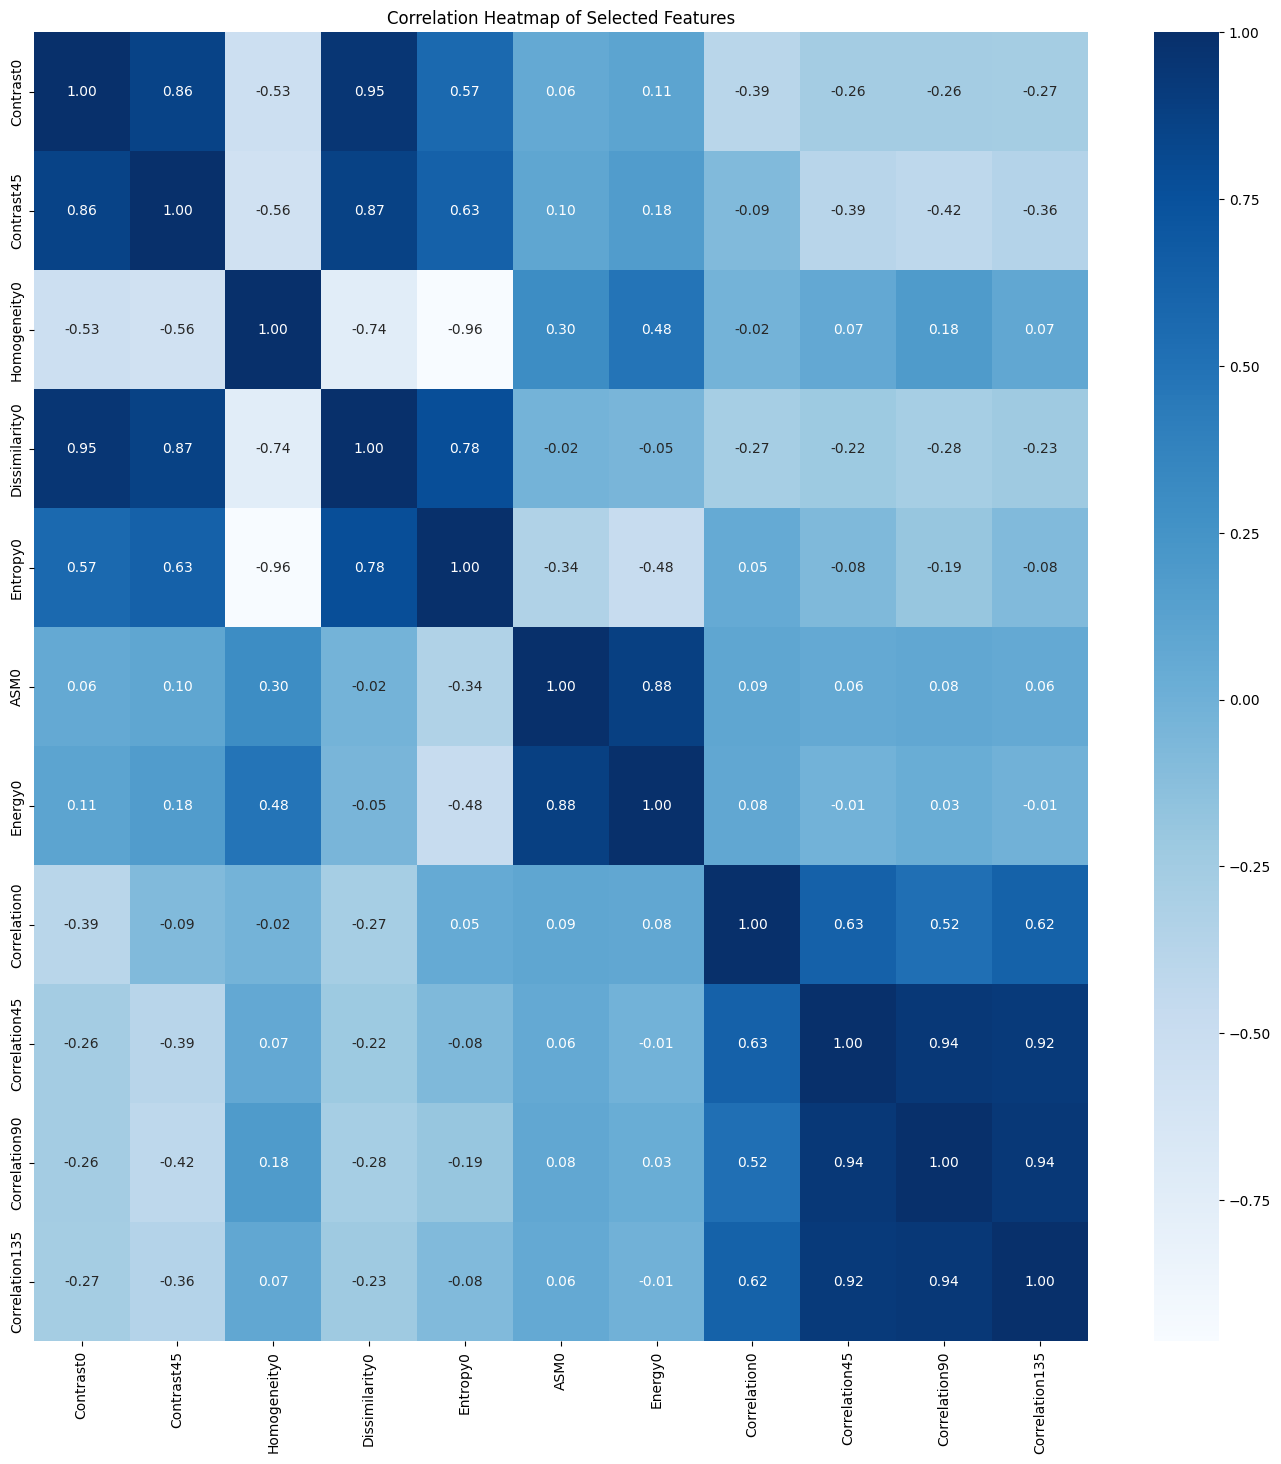

In [25]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Selected features count: {len(select)} / {correlation.shape[0]}")
print("Selected features:", list(select))
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Heatmap of Selected Features")
plt.show()


## Splitting Data


In [26]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)


Training Set Shape: (7840, 11)
Testing Set Shape: (1960, 11)


## Feature Normalization


berikut metode normalisasi yang bisa digunakan:
- Min-Max Scaling
- Standardization (Z-score)
- Robust Scaling
- MaxAbsScaler
- dll

berikut contoh menggunakan Standardization (Z-score):


In [27]:
# normalisasi mean std
# Simpan mean dan std dari X_train untuk normalisasi yang konsisten dan deployment
train_mean = X_train.mean()
train_std = X_train.std()

os.makedirs('models', exist_ok=True)
joblib.dump({'mean': train_mean, 'std': train_std}, 'models/scaler.joblib')

X_test = (X_test - train_mean) / train_std
X_train = (X_train - train_mean) / train_std
print("Normalization completed and saved!")


Normalization completed and saved!


## Modeling


### Define Model


In [28]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred, zero_division=0))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define optimized classifiers (hyperparameters tuned for maximum accuracy)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(C=10.0, kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=3, weights='uniform')


### Train Random Forest Classifier


In [29]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Save trained model
joblib.dump(rf, 'models/rf_model.joblib')

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
                     precision    recall  f1-score   support

            707-320       1.00      1.00      1.00        71
            727-200       1.00      1.00      1.00        84
            737-200       1.00      1.00      1.00        82
            737-300       1.00      1.00      1.00        76
            737-400       1.00      1.00      1.00        81
            737-500       1.00      1.00      1.00        79
            737-600       1.00      1.00      1.00        81
            737-700       1.00      1.00      1.00        70
            737-800       1.00      1.00      1.00        85
            737-900       1.00      1.00      1.00        83
            747-100       1.00      1.00      1.00        79
            747-200       1.00      1.00      1.00        76
            747-300       1.00      1.00      1.00        81
            747-400       1.00      1.00      1.00        82
            757-200       1.00      1.00      1.00        7

### Train SVM Classifier


In [30]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Save trained model
joblib.dump(svm, 'models/svm_model.joblib')

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)



------Training Set------
                     precision    recall  f1-score   support

            707-320       0.21      0.39      0.27        71
            727-200       0.18      0.19      0.18        84
            737-200       0.33      0.07      0.12        82
            737-300       0.09      0.03      0.04        76
            737-400       0.33      0.02      0.05        81
            737-500       0.13      0.09      0.11        79
            737-600       0.15      0.31      0.21        81
            737-700       0.31      0.11      0.17        70
            737-800       0.21      0.07      0.11        85
            737-900       0.16      0.19      0.17        83
            747-100       0.34      0.15      0.21        79
            747-200       0.11      0.07      0.08        76
            747-300       0.27      0.19      0.22        81
            747-400       0.16      0.05      0.07        82
            757-200       0.11      0.08      0.09        

### Train KNN Classifier


In [31]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Save trained model
joblib.dump(knn, 'models/knn_model.joblib')

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)



------Training Set------
                     precision    recall  f1-score   support

            707-320       0.35      0.97      0.51        71
            727-200       0.34      0.98      0.51        84
            737-200       0.35      0.93      0.51        82
            737-300       0.31      0.96      0.47        76
            737-400       0.33      0.91      0.49        81
            737-500       0.32      0.91      0.47        79
            737-600       0.35      0.90      0.50        81
            737-700       0.32      0.76      0.45        70
            737-800       0.36      0.81      0.50        85
            737-900       0.34      0.87      0.48        83
            747-100       0.40      0.82      0.54        79
            747-200       0.35      0.80      0.48        76
            747-300       0.36      0.77      0.49        81
            747-400       0.34      0.63      0.44        82
            757-200       0.34      0.73      0.47        

## Evaluation With Confusion Matrix


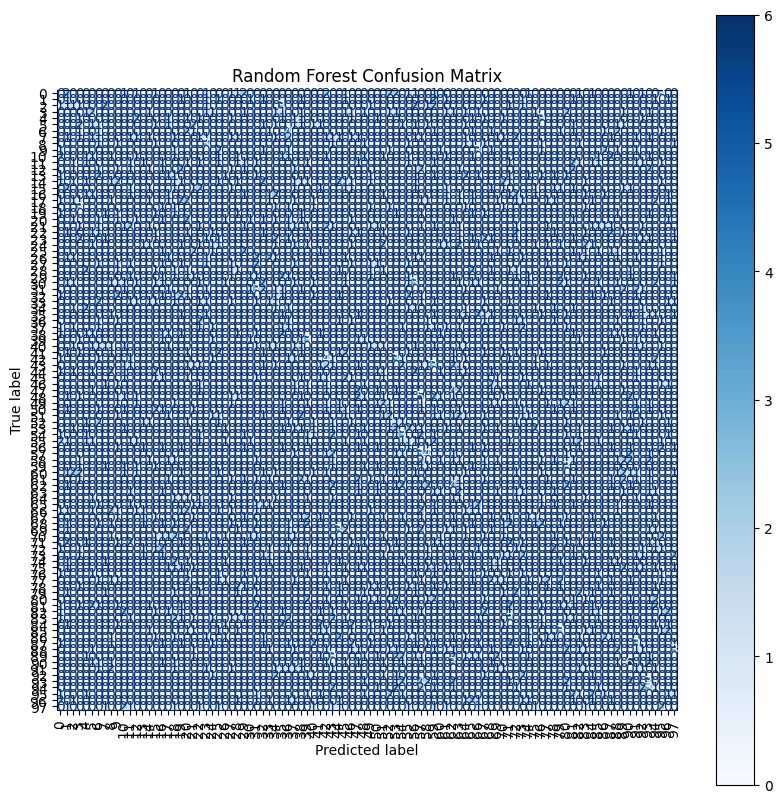

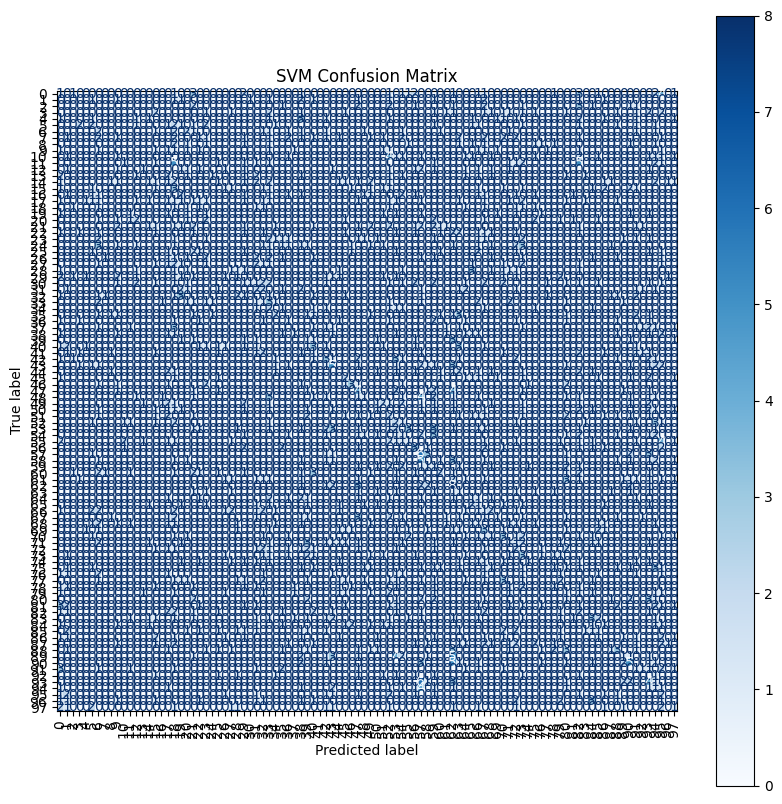

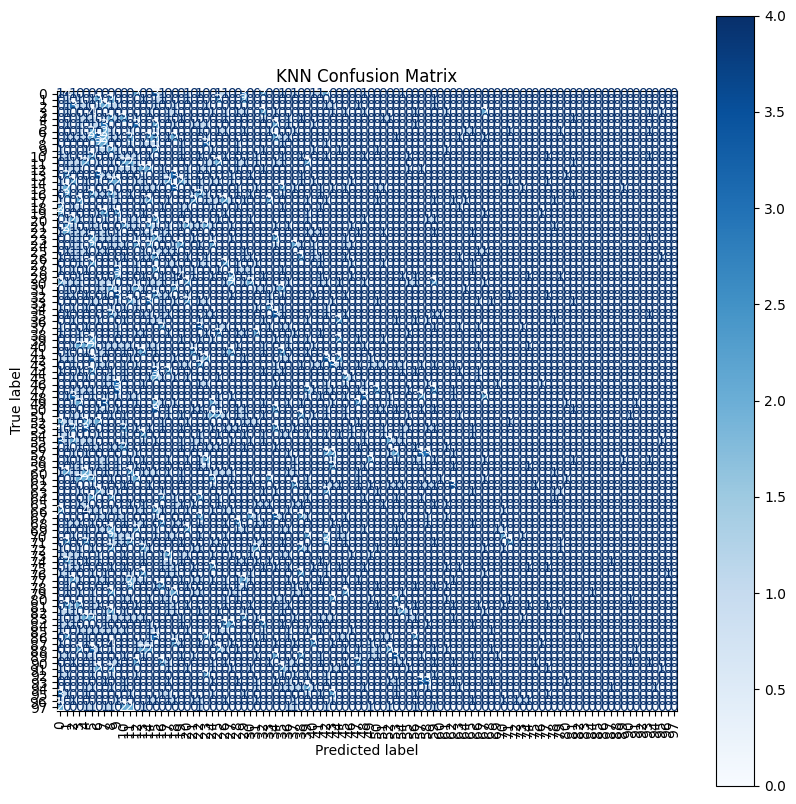

In [32]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")
